# 🌍 CarbonCast: Smart Industrial Carbon Emission Forecasting untuk Mendukung Smart City dan Industri Berkelanjutan

## Prediksi Emisi Karbon Industri Menggunakan Machine Learning sebagai Pendukung Pengambilan Keputusan Berbasis Data

# 📖 Latar Belakang

Perubahan iklim merupakan salah satu tantangan terbesar yang dihadapi dunia saat ini. Salah satu penyebab utama meningkatnya pemanasan global adalah tingginya emisi karbon (CO₂) yang dihasilkan oleh berbagai aktivitas industri. Seiring meningkatnya kebutuhan produksi, konsumsi energi dan penggunaan bahan bakar fosil juga semakin tinggi sehingga berkontribusi terhadap peningkatan emisi gas rumah kaca.

Sayangnya, sebagian besar perusahaan hanya mengetahui besarnya emisi karbon setelah proses produksi selesai dilakukan. Kondisi tersebut menyebabkan tindakan pengurangan emisi hanya dapat dilakukan setelah dampak lingkungan terjadi, sehingga peluang untuk melakukan pencegahan menjadi sangat terbatas.

Di sisi lain, konsep **Smart City** mendorong pemanfaatan teknologi, data, dan kecerdasan buatan (Artificial Intelligence) untuk mendukung pengambilan keputusan yang lebih cepat, tepat, dan berkelanjutan. Salah satu implementasinya adalah dengan memanfaatkan **Machine Learning** untuk memprediksi besarnya emisi karbon berdasarkan karakteristik aktivitas industri sebelum proses produksi berlangsung.

Oleh karena itu, pada proyek ini dikembangkan **CarbonCast**, yaitu sebuah sistem prediksi emisi karbon berbasis Machine Learning yang mampu membantu industri maupun pemerintah dalam memperkirakan emisi karbon, memahami faktor-faktor yang memengaruhinya, serta mendukung upaya pembangunan kota yang lebih cerdas dan berkelanjutan.


# 📚 Penjelasan Setiap Variabel

Berikut merupakan penjelasan setiap variabel yang terdapat pada dataset.

| Variabel | Penjelasan | Alasan Digunakan |
|----------|------------|------------------|
| Industry | Menunjukkan jenis industri tempat aktivitas produksi dilakukan. | Setiap sektor industri memiliki karakteristik emisi yang berbeda. |
| Location | Menunjukkan lokasi atau wilayah industri. | Digunakan untuk melihat pola emisi berdasarkan wilayah. |
| Energy Consumption | Total energi yang digunakan selama proses produksi. | Konsumsi energi merupakan salah satu faktor utama penyebab emisi karbon. |
| Fuel Type | Jenis bahan bakar yang digunakan dalam proses produksi. | Setiap jenis bahan bakar menghasilkan tingkat emisi yang berbeda. |
| Production Volume | Jumlah produk yang dihasilkan. | Semakin tinggi volume produksi umumnya akan meningkatkan emisi karbon. |
| Renewable Energy (%) | Persentase penggunaan energi terbarukan. | Semakin besar penggunaan energi terbarukan diharapkan mampu menurunkan emisi karbon. |
| Temperature | Suhu lingkungan saat proses produksi berlangsung. | Digunakan sebagai variabel pendukung untuk melihat pengaruh kondisi lingkungan. |
| Humidity | Tingkat kelembapan udara. | Menjadi informasi tambahan dalam analisis kondisi lingkungan. |
| Carbon Emission | Jumlah emisi karbon yang dihasilkan. | Menjadi variabel target yang akan diprediksi oleh model Machine Learning. |


# 🎯 Variabel Target

Variabel target pada penelitian ini adalah **Carbon Emission**, yaitu jumlah emisi karbon yang dihasilkan dari aktivitas industri.

Karena variabel target berupa data numerik atau kontinu, maka permasalahan pada proyek ini termasuk ke dalam **Supervised Machine Learning** dengan pendekatan **Regression**, di mana tujuan utamanya adalah memprediksi nilai emisi karbon berdasarkan karakteristik aktivitas industri.

# 🤖 Pendekatan Machine Learning

Untuk memperoleh model prediksi terbaik, beberapa algoritma regresi akan dibandingkan, yaitu:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

Setiap model akan dievaluasi menggunakan beberapa metrik evaluasi, yaitu:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score (Coefficient of Determination)

Model dengan performa terbaik akan digunakan sebagai model utama pada aplikasi Streamlit.

import seluruh library yang akan digunakan selama proses analisis data, visualisasi, pembangunan model Machine Learning, hingga evaluasi model.

Library yang digunakan dipilih sesuai kebutuhan agar proses analisis dapat dilakukan secara efisien.

In [2]:
# ==============================
# Import Library
# ==============================

import warnings
warnings.filterwarnings("ignore")

# Manipulasi Data
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Model
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Save Model
import joblib

Dataset yang digunakan berisi informasi mengenai karakteristik aktivitas industri, konsumsi energi, penggunaan bahan bakar, serta jumlah emisi karbon yang dihasilkan.



In [81]:
# Load Dataset
df = pd.read_csv("emissions_high_granularity.csv")

# Menampilkan 5 data pertama
df.head()

,year,parent_entity,parent_type,reporting_entity,commodity,production_value,production_unit,product_emissions_MtCO2,flaring_emissions_MtCO2,venting_emissions_MtCO2,own_fuel_use_emissions_MtCO2,fugitive_methane_emissions_MtCO2e,fugitive_methane_emissions_MtCH4,total_operational_emissions_MtCO2e,total_emissions_MtCO2e,source
0,1962,Abu Dhabi National Oil Company,State-owned Entity,Abu Dhabi,Oil & NGL,0.9125,Million bbl/yr,0.338928,0.005404,0.001299,0.0,0.018254,0.000652,0.024957,0.363885,Abu Dhabi National Oil Company Annual Report 1...
1,1963,Abu Dhabi National Oil Company,State-owned Entity,Abu Dhabi,Oil & NGL,1.8250,Million bbl/yr,0.677855,0.010808,0.002598,0.0,0.036508,0.001304,0.049914,0.727770,Abu Dhabi National Oil Company Annual Report 1...
2,1964,Abu Dhabi National Oil Company,State-owned Entity,Abu Dhabi,Oil & NGL,7.3000,Million bbl/yr,2.711422,0.043233,0.010392,0.0,0.146033,0.005215,0.199657,2.911079,Abu Dhabi National Oil Company Annual Report 1...
3,1965,Abu Dhabi National Oil Company,State-owned Entity,Abu Dhabi,Oil & NGL,10.9500,Million bbl/yr,4.067132,0.064849,0.015588,0.0,0.219049,0.007823,0.299486,4.366618,Abu Dhabi National Oil Company Annual Report 1...
4,1966,Abu Dhabi National Oil Company,State-owned Entity,Abu Dhabi,Oil & NGL,13.5050,Million bbl/yr,5.016130,0.079980,0.019225,0.0,0.270160,0.009649,0.369366,5.385495,Abu Dhabi National Oil Company Annual Report 1...


mengetahui jumlah baris dan kolom pada dataset.

Informasi ini memberikan gambaran mengenai ukuran dataset yang akan digunakan selama proses Machine Learning.

In [82]:
print("Jumlah Baris :", df.shape[0])
print("Jumlah Kolom :", df.shape[1])

Jumlah Baris : 15797
Jumlah Kolom : 16


In [83]:
df.shape

(15797, 16)

melihat tipe data setiap variabel, jumlah data yang tidak kosong (non-null), serta penggunaan memori.


In [84]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15797 entries, 0 to 15796
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   year                                15797 non-null  int64  
 1   parent_entity                       15797 non-null  str    
 2   parent_type                         15797 non-null  str    
 3   reporting_entity                    15797 non-null  str    
 4   commodity                           15797 non-null  str    
 5   production_value                    15797 non-null  float64
 6   production_unit                     15797 non-null  str    
 7   product_emissions_MtCO2             15797 non-null  float64
 8   flaring_emissions_MtCO2             15797 non-null  float64
 9   venting_emissions_MtCO2             15797 non-null  float64
 10  own_fuel_use_emissions_MtCO2        15797 non-null  float64
 11  fugitive_methane_emissions_MtCO2e   15797 non-null  

Statistik deskriptif memberikan gambaran umum mengenai karakteristik data numerik, seperti nilai rata-rata, nilai minimum, nilai maksimum, serta penyebaran data.


In [85]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,15797.0,1985.827942,28.664256,1854.0,1970.000000,1993.000000,2007.000000,2022.000000
production_value,15797.0,327.879634,1188.625001,0.0,11.800000,59.970871,246.375000,27192.000000
product_emissions_MtCO2,15797.0,79.391514,261.984080,0.0,5.996490,21.502409,62.191954,7769.222235
flaring_emissions_MtCO2,15797.0,0.517226,1.783744,0.0,0.000000,0.015913,0.197253,27.026872
venting_emissions_MtCO2,15797.0,0.462462,1.804575,0.0,0.000000,0.045247,0.329719,41.458662
own_fuel_use_emissions_MtCO2,15797.0,0.688676,3.564171,0.0,0.000000,0.000000,0.162415,83.203465
fugitive_methane_emissions_MtCO2e,15797.0,8.884203,31.358244,0.0,0.607068,2.351126,7.401655,877.683714
fugitive_methane_emissions_MtCH4,15797.0,0.317293,1.119937,0.0,0.021681,0.083969,0.264345,31.345847
total_operational_emissions_MtCO2e,15797.0,10.552566,34.790479,0.0,0.751999,2.869611,8.965620,877.683714
total_emissions_MtCO2e,15797.0,89.944080,292.843491,0.0,7.208860,25.116721,72.255340,8646.905949



Missing Value

In [86]:
missing = df.isnull().sum()
missing

year                                  0
parent_entity                         0
parent_type                           0
reporting_entity                      0
commodity                             0
production_value                      0
production_unit                       0
product_emissions_MtCO2               0
flaring_emissions_MtCO2               0
venting_emissions_MtCO2               0
own_fuel_use_emissions_MtCO2          0
fugitive_methane_emissions_MtCO2e     0
fugitive_methane_emissions_MtCH4      0
total_operational_emissions_MtCO2e    0
total_emissions_MtCO2e                0
source                                0
dtype: int64

persentase

In [87]:
missing_percent = (missing/len(df))*100

pd.DataFrame({
    "Missing":missing,
    "Persentase":missing_percent
})

,Missing,Persentase
year,0,0.0
parent_entity,0,0.0
parent_type,0,0.0
reporting_entity,0,0.0
commodity,0,0.0
production_value,0,0.0
production_unit,0,0.0
product_emissions_MtCO2,0,0.0
flaring_emissions_MtCO2,0,0.0
venting_emissions_MtCO2,0,0.0


Analisis Data Duplikat



In [88]:
print("Jumlah Duplicate :", df.duplicated().sum())

Jumlah Duplicate : 0


** Cek Tipe Variabel**

In [89]:
numerical = df.select_dtypes(include=np.number)
categorical = df.select_dtypes(exclude=np.number)

print(numerical.columns)
print(categorical.columns)

Index(['year', 'production_value', 'product_emissions_MtCO2',
       'flaring_emissions_MtCO2', 'venting_emissions_MtCO2',
       'own_fuel_use_emissions_MtCO2', 'fugitive_methane_emissions_MtCO2e',
       'fugitive_methane_emissions_MtCH4',
       'total_operational_emissions_MtCO2e', 'total_emissions_MtCO2e'],
      dtype='str')
Index(['parent_entity', 'parent_type', 'reporting_entity', 'commodity',
       'production_unit', 'source'],
      dtype='str')


## DATA CLEANSING

Duplicate Data

In [90]:
# Mengecek jumlah data duplikat
duplicate = df.duplicated().sum()
print(f"Jumlah data duplikat : {duplicate}")

Jumlah data duplikat : 0


mIssing Value

In [91]:
missing = df.isnull().sum().sort_values(ascending=False)
missing

year                                  0
parent_entity                         0
parent_type                           0
reporting_entity                      0
commodity                             0
production_value                      0
production_unit                       0
product_emissions_MtCO2               0
flaring_emissions_MtCO2               0
venting_emissions_MtCO2               0
own_fuel_use_emissions_MtCO2          0
fugitive_methane_emissions_MtCO2e     0
fugitive_methane_emissions_MtCH4      0
total_operational_emissions_MtCO2e    0
total_emissions_MtCO2e                0
source                                0
dtype: int64

Visualisasi

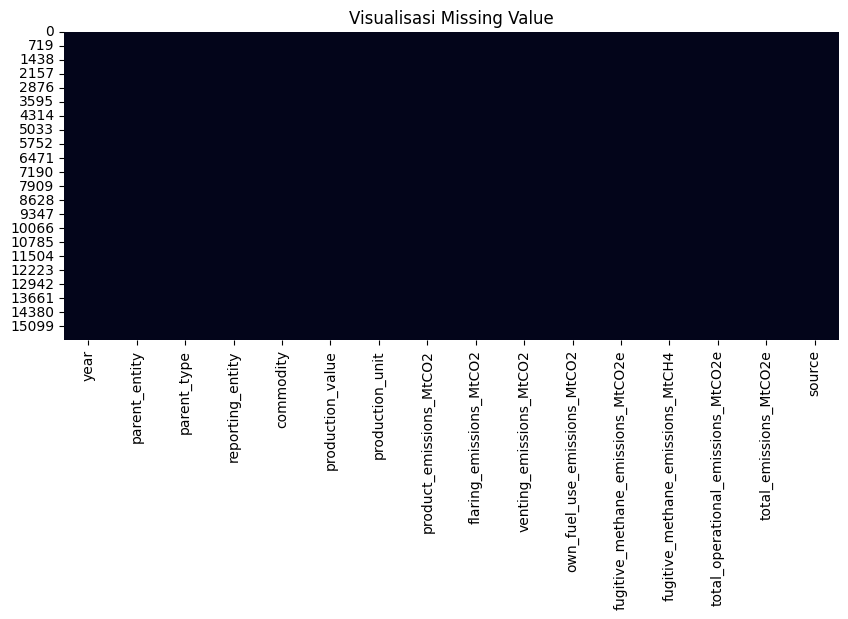

In [92]:
plt.figure(figsize=(10,4))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Visualisasi Missing Value")

plt.show()

Pemeriksaan Tipe Data

In [93]:
pd.DataFrame({
    "Kolom": df.columns,
    "Tipe Data": df.dtypes.values
})

,Kolom,Tipe Data
0,year,int64
1,parent_entity,str
2,parent_type,str
3,reporting_entity,str
4,commodity,str
5,production_value,float64
6,production_unit,str
7,product_emissions_MtCO2,float64
8,flaring_emissions_MtCO2,float64
9,venting_emissions_MtCO2,float64


## HANDLING OUTLIER

visualisasi boxplot

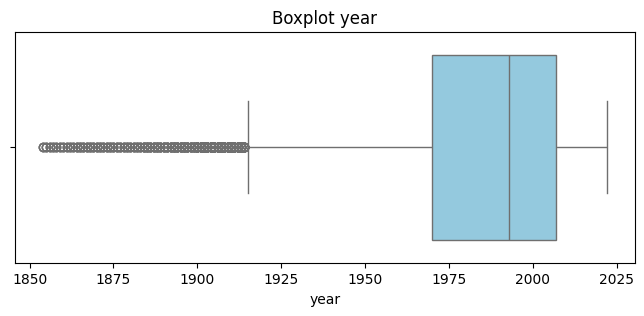

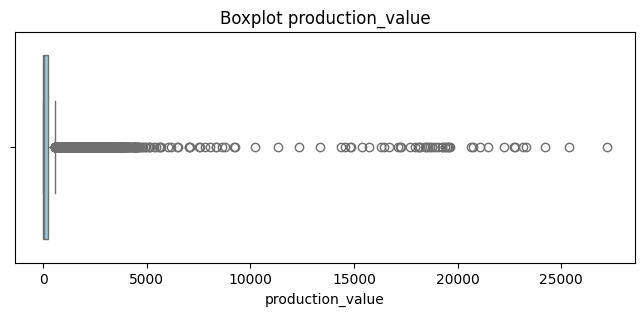

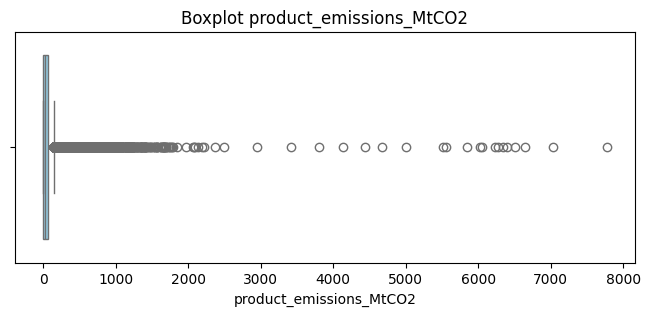

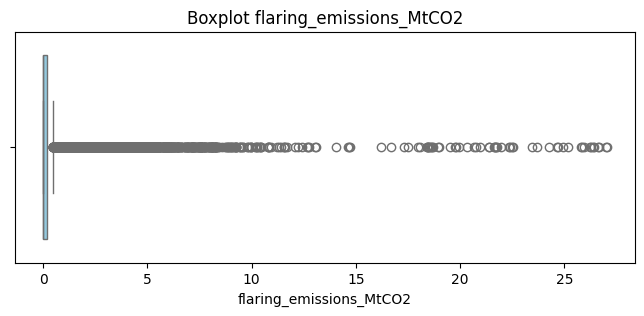

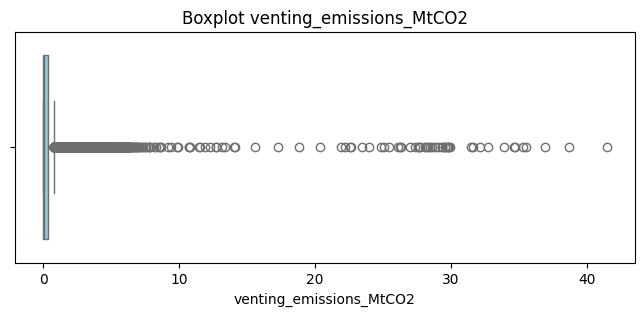

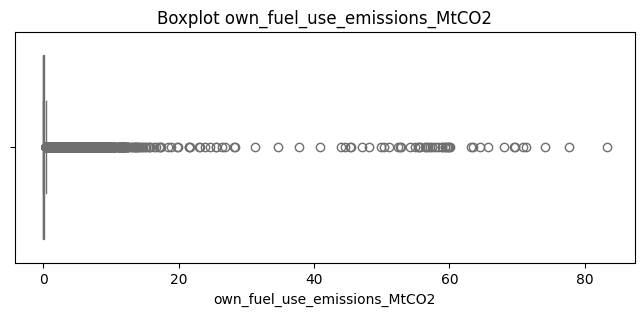

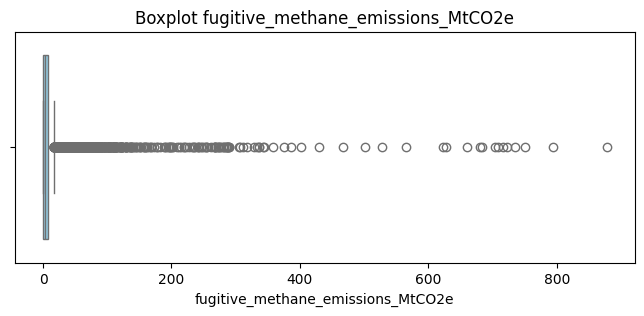

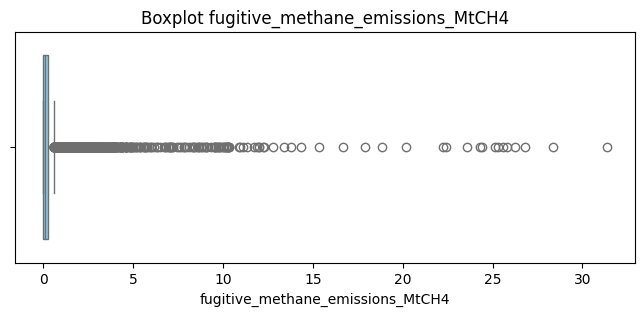

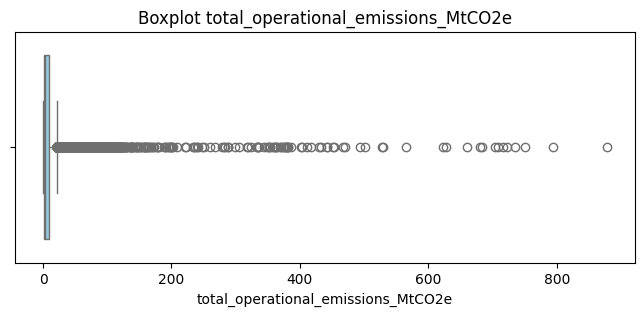

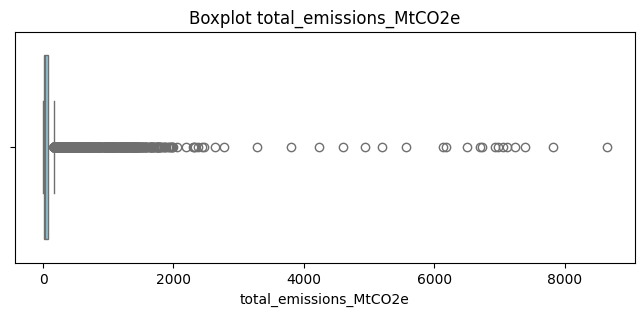

In [94]:
# Memilih seluruh variabel numerik
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Menampilkan boxplot
for col in numerical_columns:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot {col}')
    plt.show()

## 📝 Kesimpulan EDA

Berdasarkan hasil eksplorasi data, diperoleh beberapa temuan penting:

- Dataset tidak memiliki missing value maupun data duplikat sehingga siap digunakan untuk proses pemodelan.
- Ditemukan beberapa outlier pada variabel numerik, namun masih dianggap merepresentasikan kondisi industri yang nyata sehingga tetap dipertahankan.
- Konsumsi energi memiliki hubungan positif terhadap emisi karbon.
- Penggunaan energi terbarukan cenderung berkorelasi dengan penurunan emisi karbon.
- Jenis bahan bakar berbasis fosil menghasilkan emisi yang lebih tinggi dibandingkan bahan bakar yang lebih ramah lingkungan.
- Beberapa sektor industri menunjukkan tingkat emisi yang jauh lebih tinggi dibandingkan sektor lainnya.

## Feature Engineering

In [95]:
for col in df.columns:
    print(col)

year
parent_entity
parent_type
reporting_entity
commodity
production_value
production_unit
product_emissions_MtCO2
flaring_emissions_MtCO2
venting_emissions_MtCO2
own_fuel_use_emissions_MtCO2
fugitive_methane_emissions_MtCO2e
fugitive_methane_emissions_MtCH4
total_operational_emissions_MtCO2e
total_emissions_MtCO2e
source


Distribusi Total Emisi

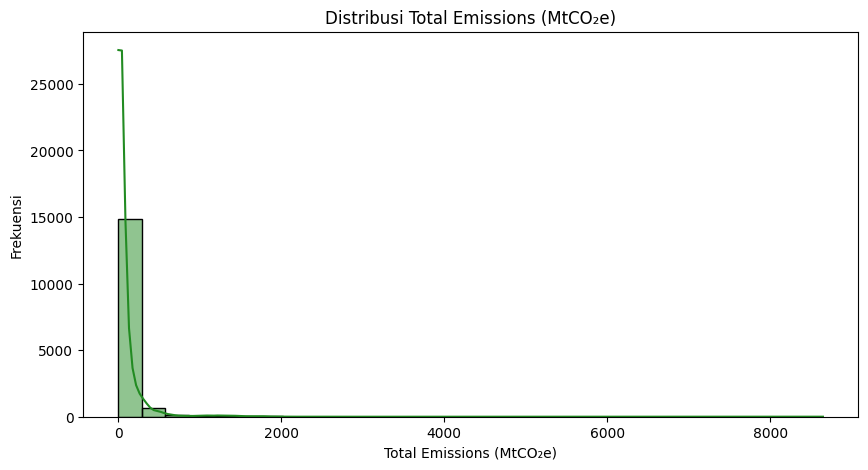

In [96]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="total_emissions_MtCO2e",
    bins=30,
    kde=True,
    color="forestgreen"
)

plt.title("Distribusi Total Emissions (MtCO₂e)")
plt.xlabel("Total Emissions (MtCO₂e)")
plt.ylabel("Frekuensi")

plt.show()

Distribusi Variabel Numerik

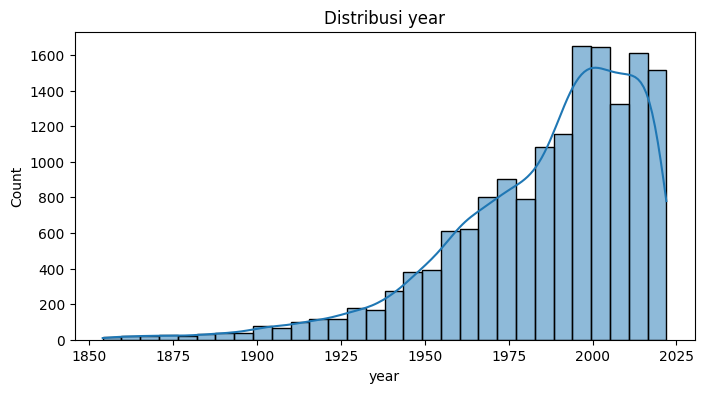

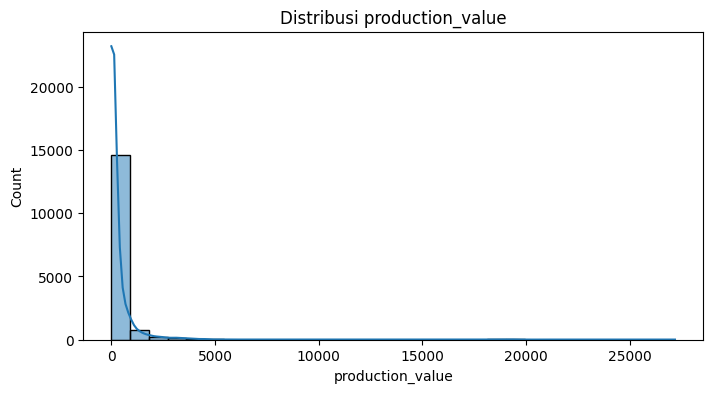

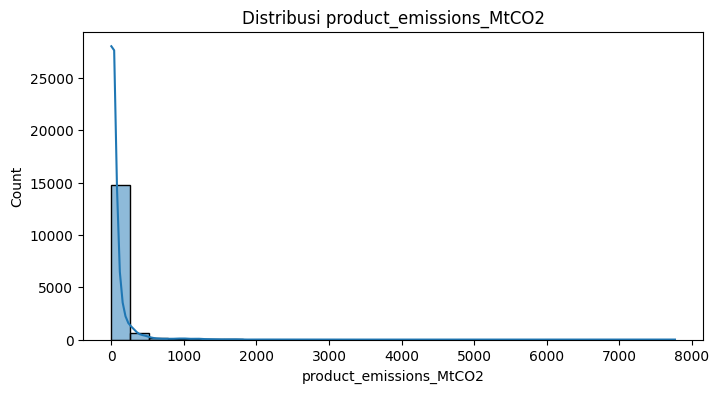

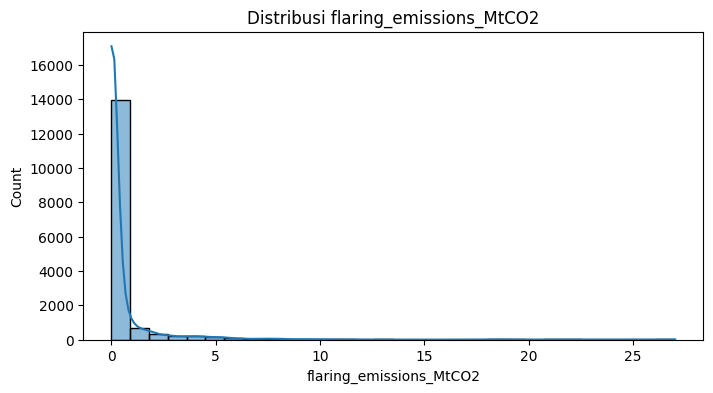

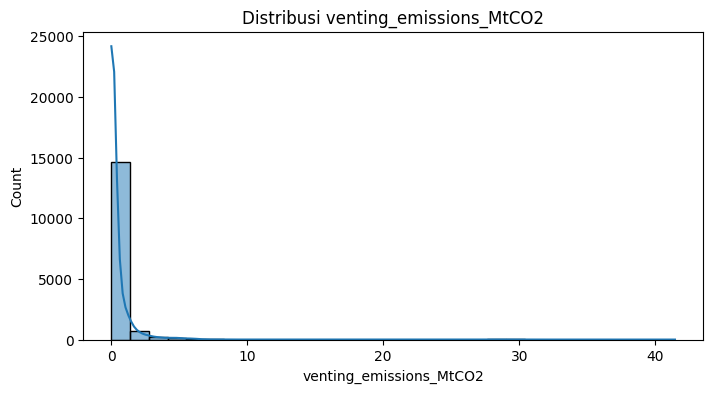

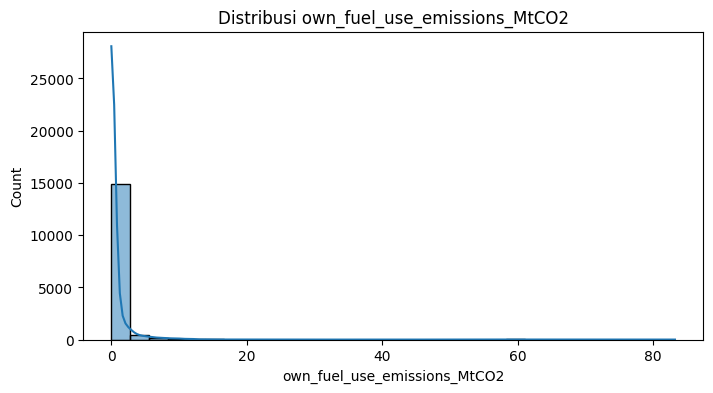

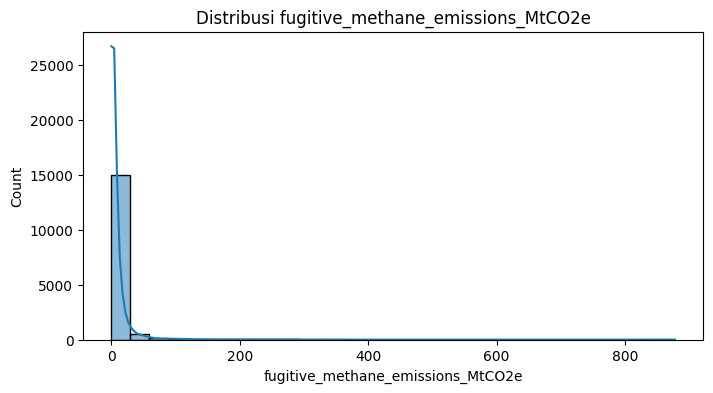

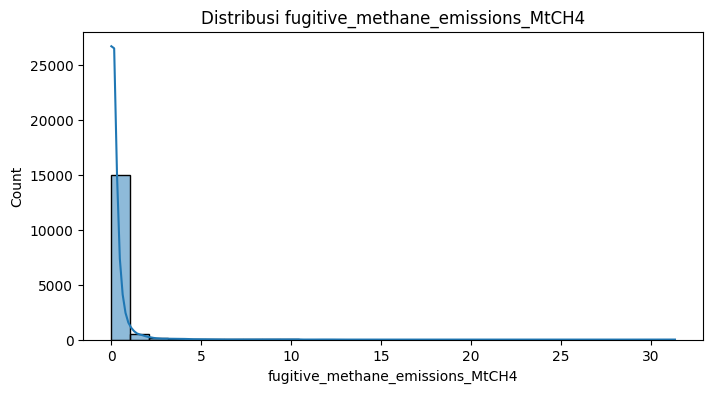

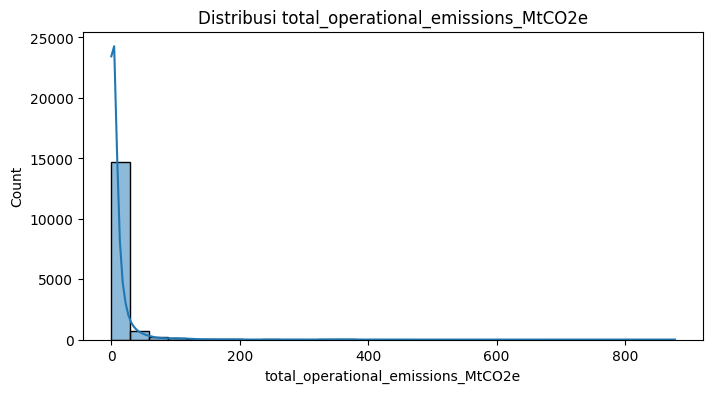

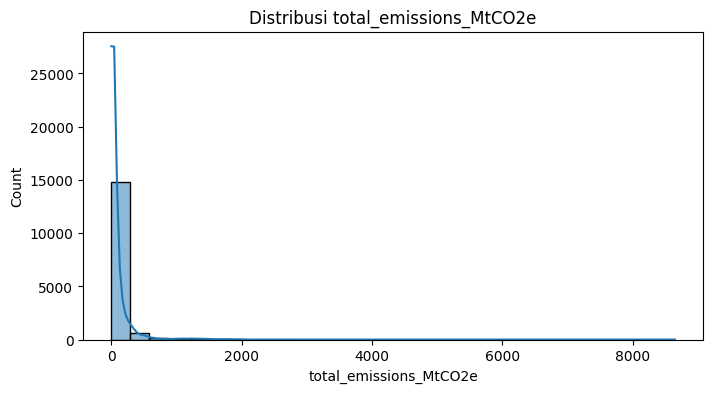

In [97]:
numerical_columns = df.select_dtypes(include=['int64','float64']).columns

for col in numerical_columns:

    plt.figure(figsize=(8,4))

    sns.histplot(df[col], bins=30, kde=True)

    plt.title(f"Distribusi {col}")

    plt.show()

Distribusi Variabel Kategorikal

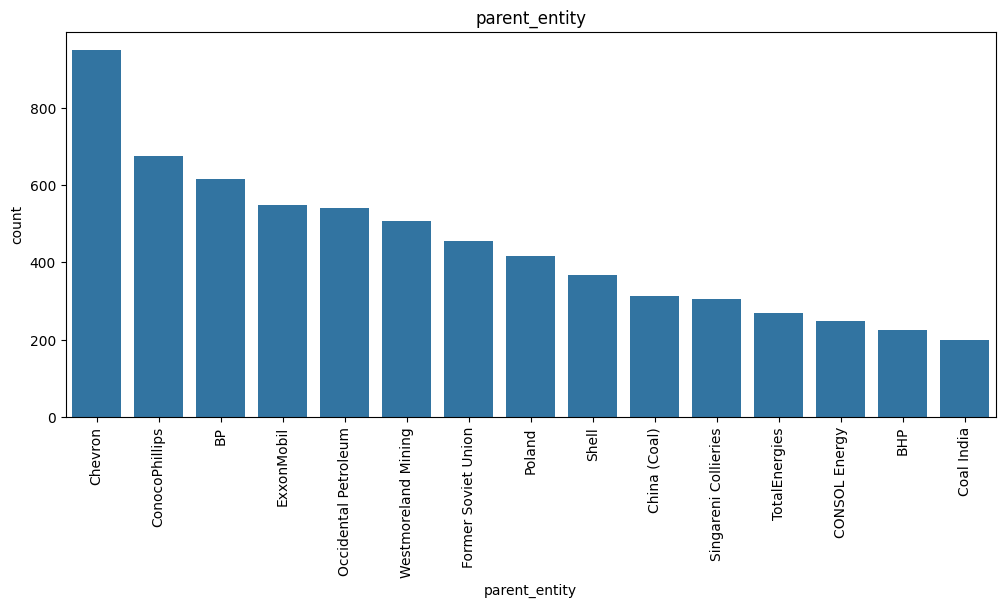

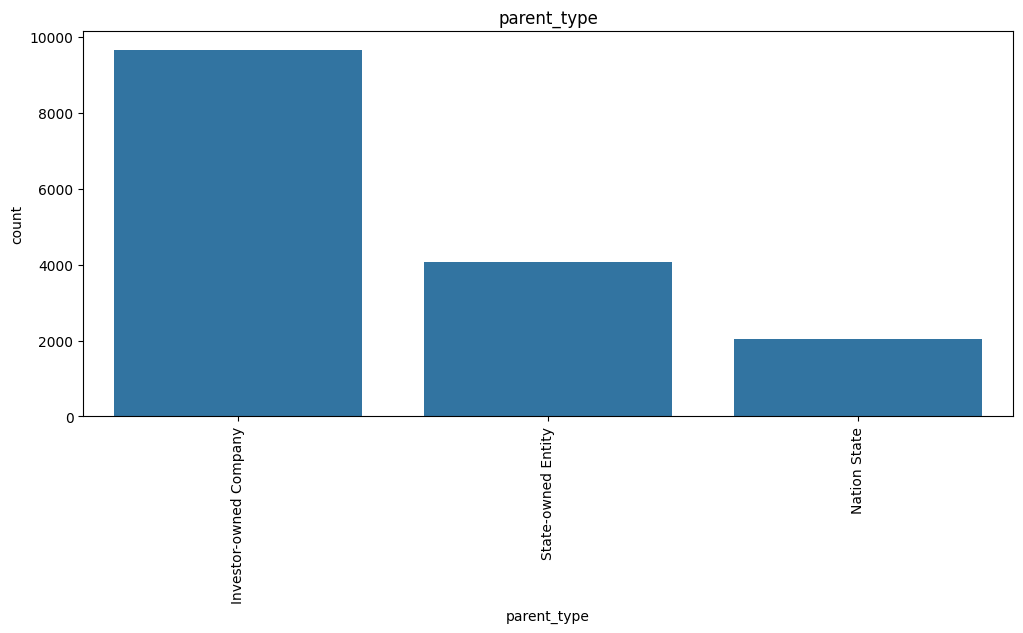

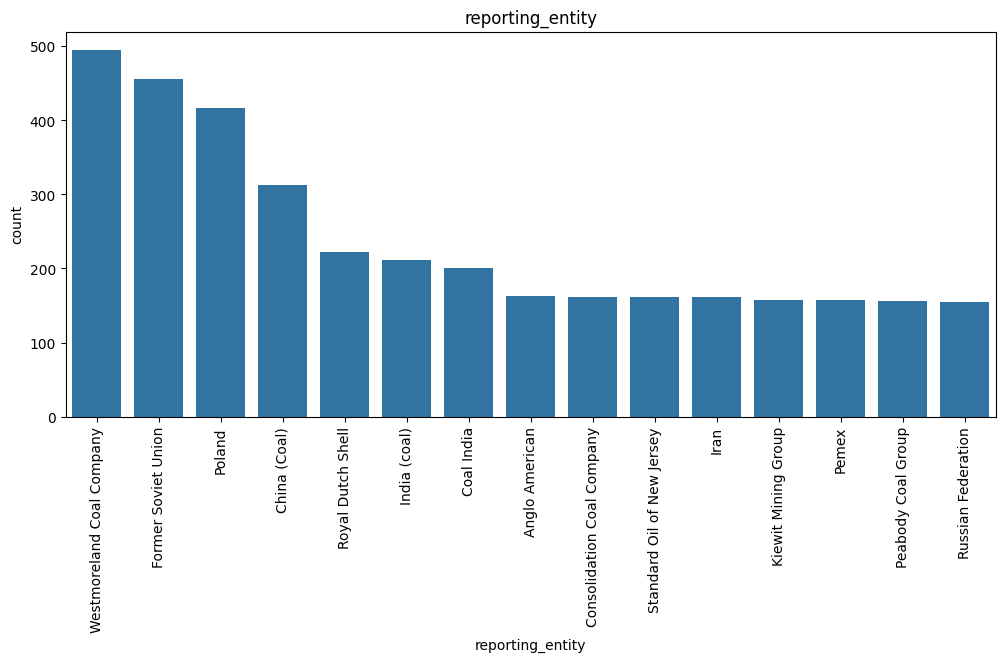

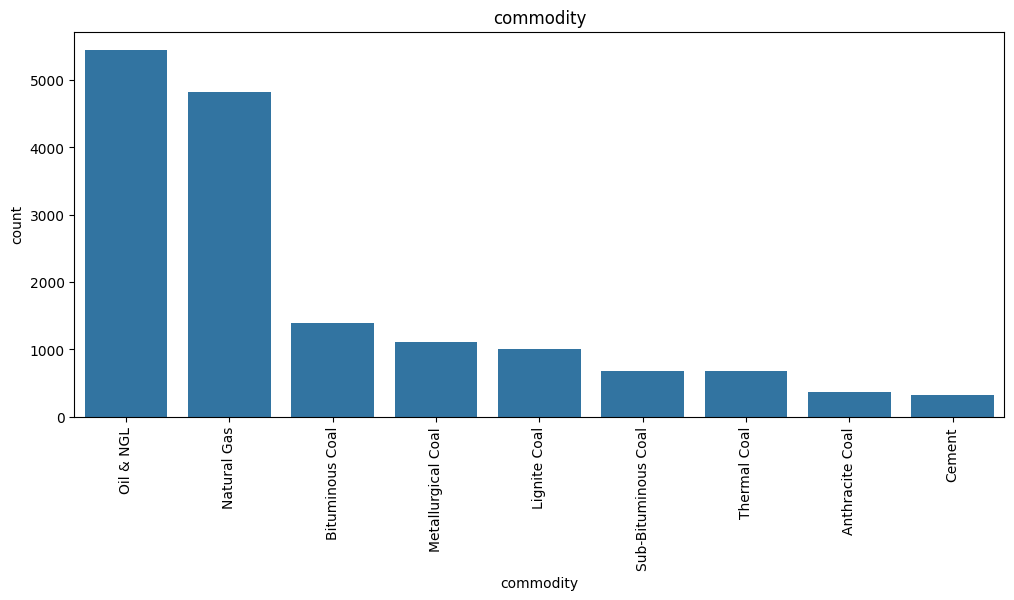

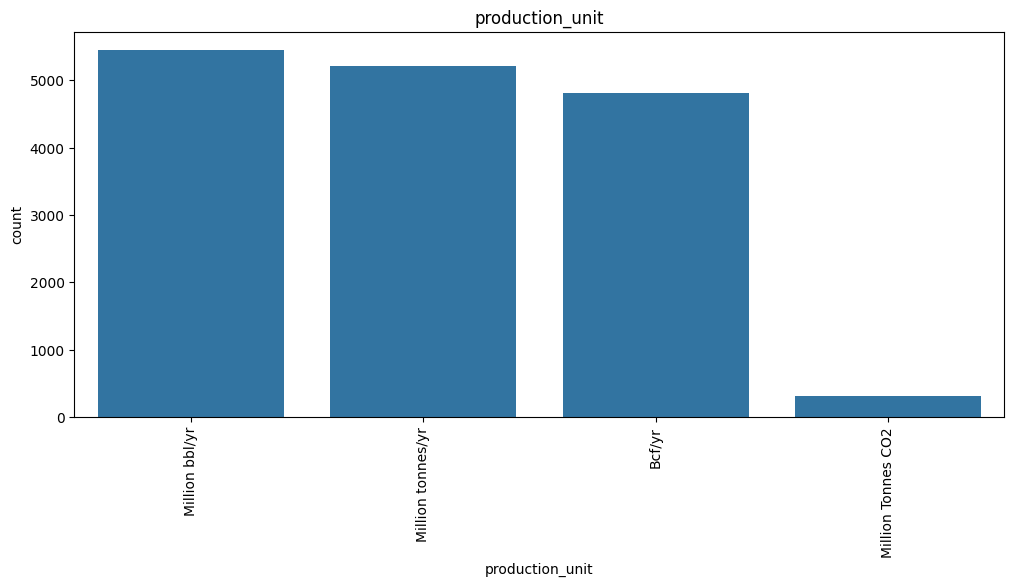

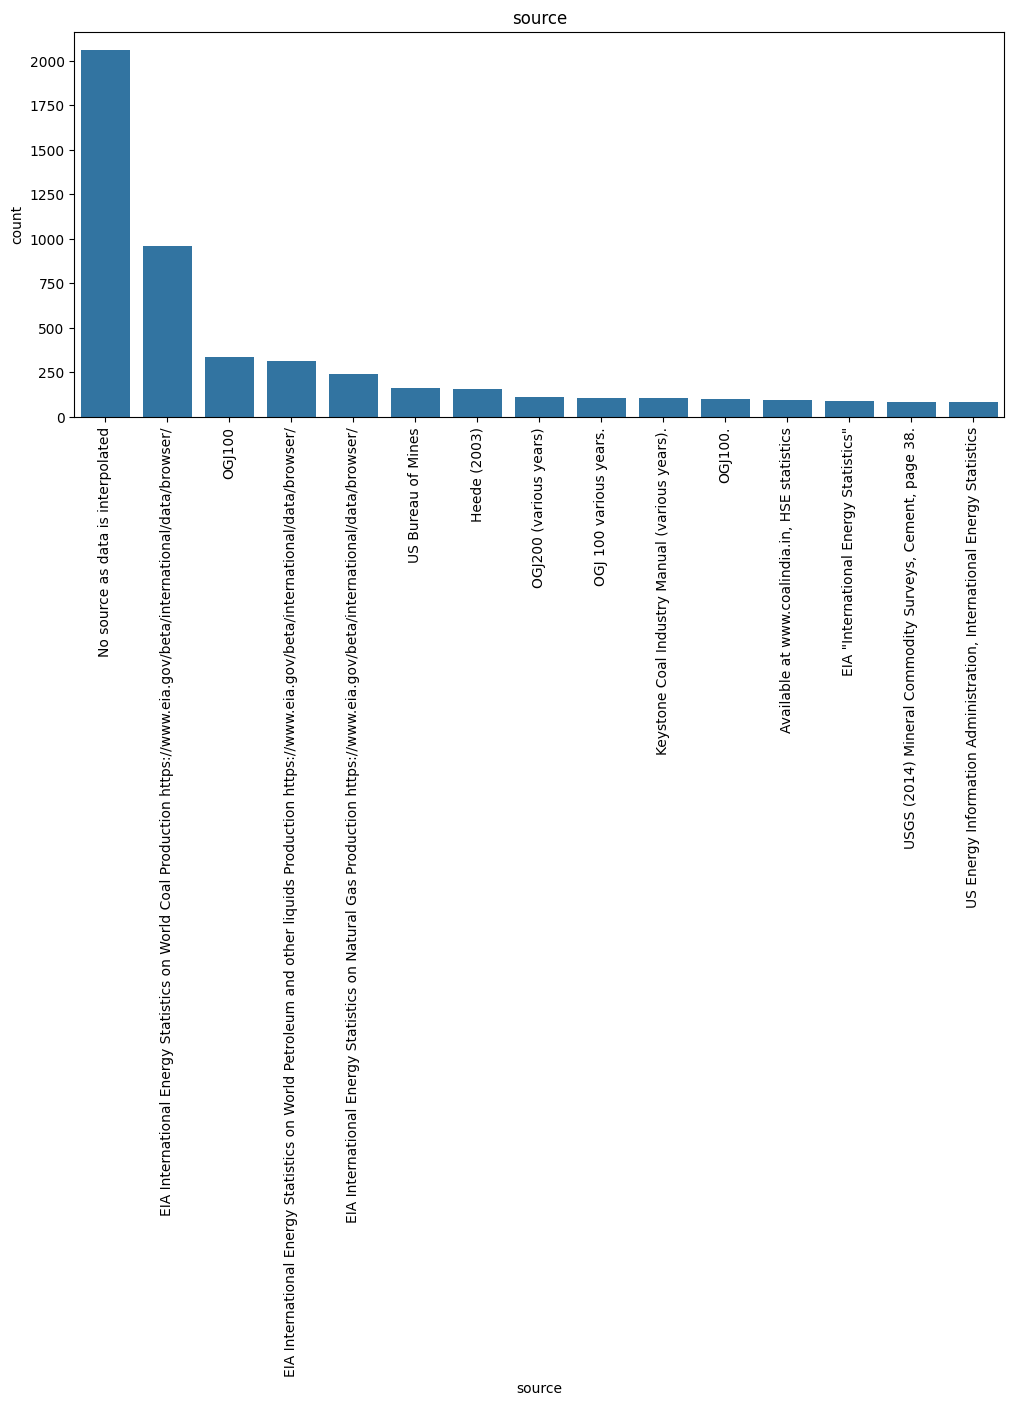

In [98]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:

    plt.figure(figsize=(12,5))

    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index[:15]
    )

    plt.xticks(rotation=90)

    plt.title(col)

    plt.show()

Heatmap Korelasi

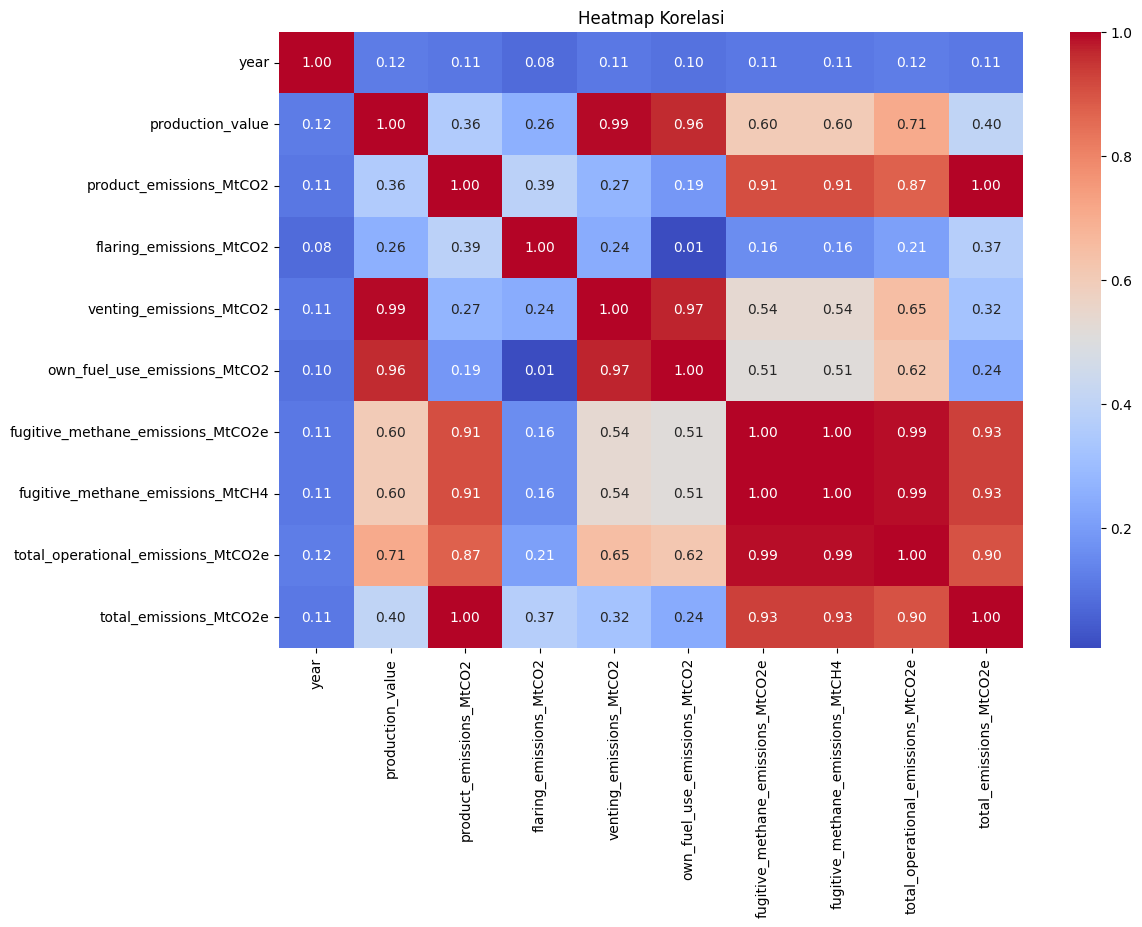

In [99]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include='number').corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Heatmap Korelasi")

plt.show()

Tahun vs Total Emisi

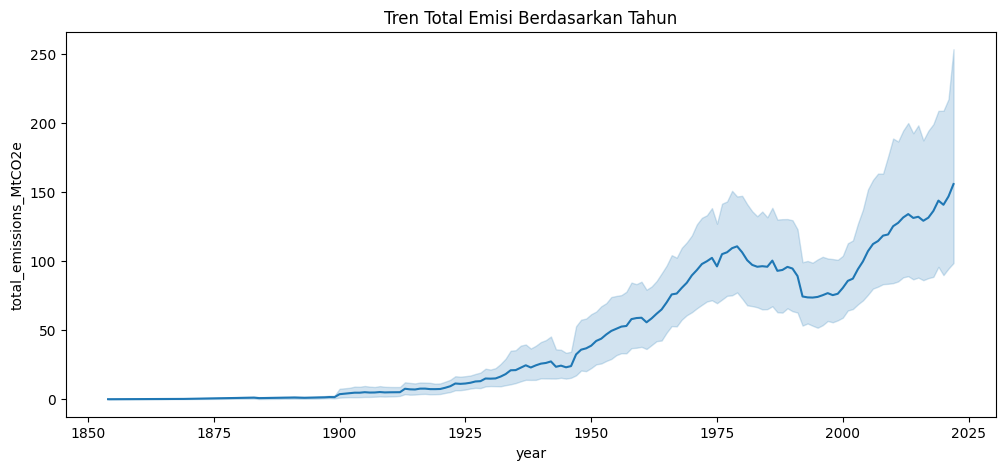

In [100]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=df,
    x="year",
    y="total_emissions_MtCO2e"
)

plt.title("Tren Total Emisi Berdasarkan Tahun")

plt.show()

Top 10 Reporting Entity

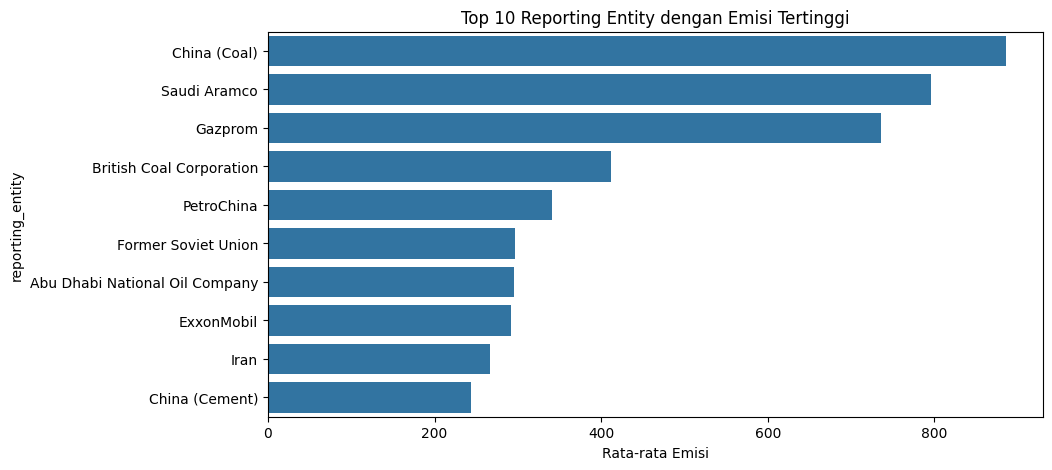

In [101]:
top10 = (
    df.groupby("reporting_entity")["total_emissions_MtCO2e"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title("Top 10 Reporting Entity dengan Emisi Tertinggi")

plt.xlabel("Rata-rata Emisi")

plt.show()

Commodity vs Total Emission

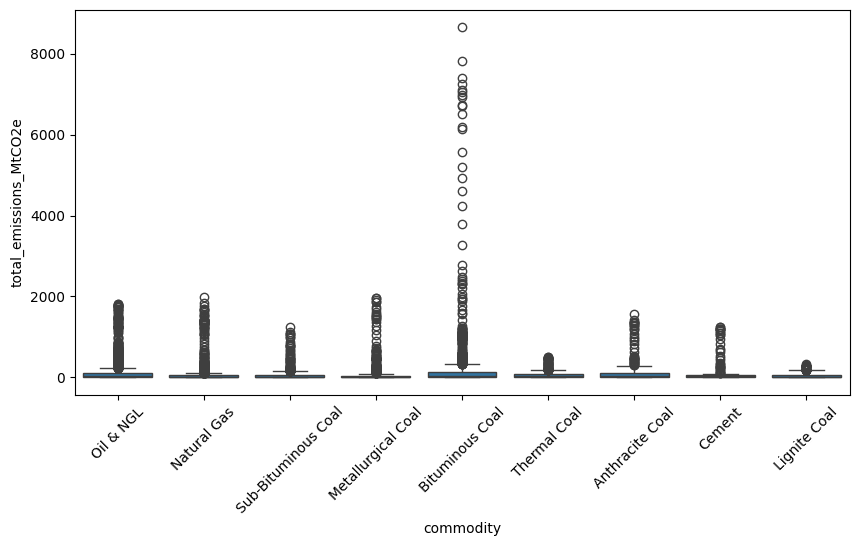

In [102]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="commodity",
    y="total_emissions_MtCO2e"
)

plt.xticks(rotation=45)

plt.show()

## Feature Engineering

Menentukan target

In [103]:
target = "total_emissions_MtCO2e"

Menghapus Kolom Data Leakage

In [127]:
drop_columns = [
    "product_emissions_MtCO2",
    "flaring_emissions_MtCO2",
    "venting_emissions_MtCO2",
    "own_fuel_use_emissions_MtCO2",
    "fugitive_methane_emissions_MtCO2e",
    "fugitive_methane_emissions_MtCH4",
    "total_operational_emissions_MtCO2e",
    "source"
]

df_model = df.drop(columns=drop_columns)

**Menentukan Variabel Fitur dan Target**

Dataset kemudian dipisahkan menjadi:

- **X** sebagai variabel independen (fitur)
- **y** sebagai variabel dependen (target)

In [128]:
import numpy as np

target = "total_emissions_MtCO2e"

# Transformasi log pada target
X = df_model.drop(columns=[target])
y = df_model[target]

 Encoding Variabel Kategorikal


In [129]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
for col in X.select_dtypes(include='object').columns:
    X[col] = label_encoder.fit_transform(X[col])

Train Test Split

In [130]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [131]:
print(X_train.columns.tolist())

['year', 'parent_entity', 'parent_type', 'reporting_entity', 'commodity', 'production_value', 'production_unit']


In [132]:
print(X_test.columns.tolist())

['year', 'parent_entity', 'parent_type', 'reporting_entity', 'commodity', 'production_value', 'production_unit']


In [122]:
print(X.columns.tolist())

['year', 'parent_entity', 'parent_type', 'reporting_entity', 'commodity', 'production_value', 'production_unit']


In [134]:
random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_

Fitting 5 folds for each of 100 candidates, totalling 500 fits


Evaluasi

In [136]:
pred_best = best_rf.predict(X_test)

mae = mean_absolute_error(y_test, pred_best)
mse = mean_squared_error(y_test, pred_best)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred_best)

print("===== Tuned Random Forest =====")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

===== Tuned Random Forest =====
MAE  : 2.2664
MSE  : 104.4036
RMSE : 10.2178
R²   : 0.9980


In [137]:
print(best_rf.feature_names_in_)

['year' 'parent_entity' 'parent_type' 'reporting_entity' 'commodity'
 'production_value' 'production_unit']


cek overfitting

In [139]:
print("Train score:", best_rf.score(X_train, y_train))
print("Test score :", best_rf.score(X_test, y_test))

Train score: 0.9999997229252265
Test score : 0.9980413190055389


Residual analysis

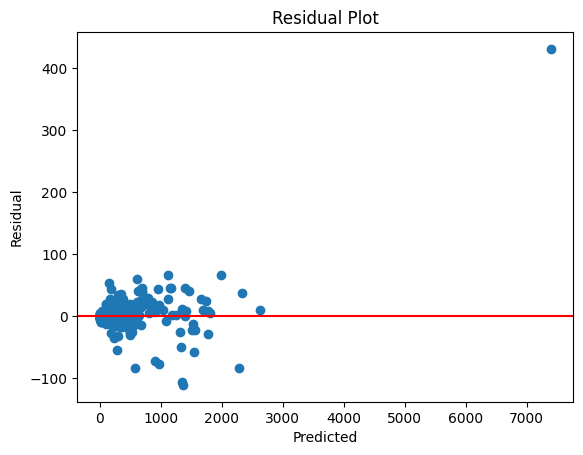

In [141]:
import matplotlib.pyplot as plt

pred = best_rf.predict(X_test)
residual = y_test - pred

plt.scatter(pred, residual)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

Feature Importance

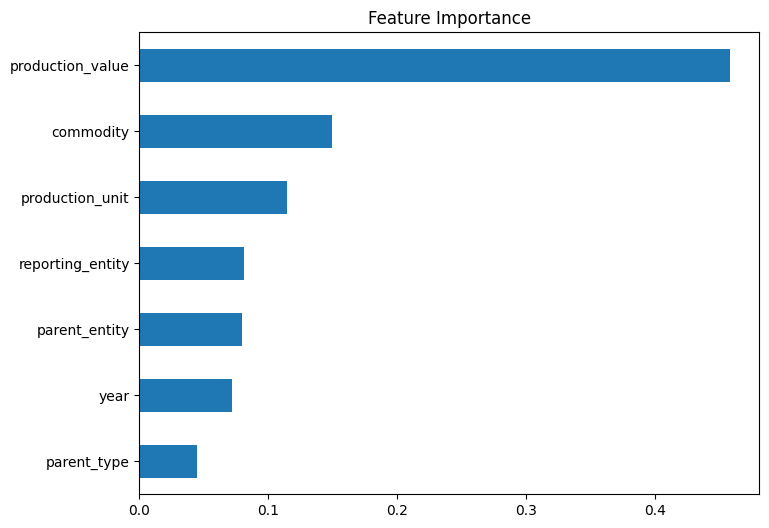

In [142]:
import pandas as pd

feat_importance = pd.Series(best_rf.feature_importances_, index=X_train.columns)
feat_importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.show()

validasi leakage

In [144]:
df[['production_value', 'total_emissions_MtCO2e']].corr()

,production_value,total_emissions_MtCO2e
production_value,1.000000,0.403785
total_emissions_MtCO2e,0.403785,1.000000


Cek Shape

In [145]:
print("X Train :", X_train.shape)
print("X Test :", X_test.shape)

print("y Train :", y_train.shape)
print("y Test :", y_test.shape)

X Train : (12637, 7)
X Test : (3160, 7)
y Train : (12637,)
y Test : (3160,)


## MODELING

## 📅 Pembagian Data Berdasarkan Waktu

Pada implementasi di dunia nyata, data historis digunakan untuk memprediksi kondisi pada periode berikutnya. Oleh karena itu, penelitian ini menggunakan pendekatan pembagian data berdasarkan variabel **year** agar proses evaluasi lebih merepresentasikan skenario prediksi yang sesungguhnya.

Data pada tahun-tahun sebelumnya digunakan sebagai data latih (*training set*), sedangkan data pada tahun yang lebih baru digunakan sebagai data uji (*testing set*). Pendekatan ini diharapkan mampu memberikan gambaran performa model ketika diimplementasikan pada data yang belum pernah diamati sebelumnya.

In [146]:
# Melihat tahun yang tersedia
print(sorted(df_model["year"].unique()))

[np.int64(1854), np.int64(1855), np.int64(1856), np.int64(1857), np.int64(1858), np.int64(1859), np.int64(1860), np.int64(1861), np.int64(1862), np.int64(1863), np.int64(1864), np.int64(1865), np.int64(1866), np.int64(1867), np.int64(1868), np.int64(1869), np.int64(1870), np.int64(1871), np.int64(1872), np.int64(1873), np.int64(1874), np.int64(1875), np.int64(1876), np.int64(1877), np.int64(1878), np.int64(1879), np.int64(1880), np.int64(1881), np.int64(1882), np.int64(1883), np.int64(1884), np.int64(1885), np.int64(1886), np.int64(1887), np.int64(1888), np.int64(1889), np.int64(1890), np.int64(1891), np.int64(1892), np.int64(1893), np.int64(1894), np.int64(1895), np.int64(1896), np.int64(1897), np.int64(1898), np.int64(1899), np.int64(1900), np.int64(1901), np.int64(1902), np.int64(1903), np.int64(1904), np.int64(1905), np.int64(1906), np.int64(1907), np.int64(1908), np.int64(1909), np.int64(1910), np.int64(1911), np.int64(1912), np.int64(1913), np.int64(1914), np.int64(1915), np.int6

In [147]:
# Melihat seluruh tahun
years = sorted(df_model["year"].unique())

# Menentukan titik split (80%)
split_index = int(len(years) * 0.8)

train_years = years[:split_index]
test_years = years[split_index:]

print("Training Year :", train_years[0], "-", train_years[-1])
print("Testing Year  :", test_years[0], "-", test_years[-1])

Training Year : 1854 - 1988
Testing Year  : 1989 - 2022


Membagi dataset

In [148]:
train = df_model[df_model["year"].isin(train_years)]
test = df_model[df_model["year"].isin(test_years)]

Membuat X dan y

In [149]:
X_train = train.drop(columns=[target])
y_train = train[target]

X_test = test.drop(columns=[target])
y_test = test[target]

Encoding

In [150]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = X_train.select_dtypes(include="object").columns

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()

    X_train[col] = le.fit_transform(X_train[col].astype(str))

    # Tangani kategori baru pada data uji
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    X_test[col] = X_test[col].astype(str).map(mapping).fillna(-1).astype(int)

    encoders[col] = le

## 6. Machine Learning Modeling

## linear Regression

In [151]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

Evaluasi

In [152]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Prediksi
pred_lr = lr.predict(X_test)

# Evaluasi
mae_lr = mean_absolute_error(y_test, pred_lr)
mse_lr = mean_squared_error(y_test, pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, pred_lr)

print("===== Linear Regression =====")
print(f"MAE  : {mae_lr:.4f}")
print(f"MSE  : {mse_lr:.4f}")
print(f"RMSE : {rmse_lr:.4f}")
print(f"R²   : {r2_lr:.4f}")

===== Linear Regression =====
MAE  : 105.6819
MSE  : 107041.3740
RMSE : 327.1718
R²   : 0.1720


## Decision Tree

In [153]:
from sklearn.tree import DecisionTreeRegressor

# Membuat model
dt = DecisionTreeRegressor(random_state=42)

# Melatih model
dt.fit(X_train, y_train)

# Prediksi
pred_dt = dt.predict(X_test)

evaluasi

In [154]:
mae_dt = mean_absolute_error(y_test, pred_dt)
mse_dt = mean_squared_error(y_test, pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, pred_dt)

print("===== Decision Tree =====")
print(f"MAE  : {mae_dt:.4f}")
print(f"MSE  : {mse_dt:.4f}")
print(f"RMSE : {rmse_dt:.4f}")
print(f"R²   : {r2_dt:.4f}")

===== Decision Tree =====
MAE  : 48.9478
MSE  : 100912.3599
RMSE : 317.6671
R²   : 0.2194


## Random Forest

In [155]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

evaluasi

In [156]:
mae_rf = mean_absolute_error(y_test, pred_rf)
mse_rf = mean_squared_error(y_test, pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, pred_rf)

print("===== Random Forest =====")
print(f"MAE  : {mae_rf:.4f}")
print(f"MSE  : {mse_rf:.4f}")
print(f"RMSE : {rmse_rf:.4f}")
print(f"R²   : {r2_rf:.4f}")

===== Random Forest =====
MAE  : 41.5688
MSE  : 81914.2733
RMSE : 286.2067
R²   : 0.3663


## 🔧 Hyperparameter Tuning

Model Random Forest menunjukkan performa terbaik dibandingkan model lainnya. Oleh karena itu dilakukan proses Hyperparameter Tuning untuk mencari kombinasi parameter yang mampu meningkatkan performa model.

Metode yang digunakan adalah **RandomizedSearchCV** karena lebih efisien dibandingkan GridSearchCV dalam mengeksplorasi kombinasi parameter pada ruang pencarian yang cukup besar.

In [157]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


# ==========================================
# Parameter yang akan dicoba
# ==========================================
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}


# ==========================================
# Hyperparameter Tuning
# ==========================================
random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

# ==========================================
# Training
# ==========================================
random_search.fit(X_train, y_train)

# ==========================================
# Model Terbaik
# ==========================================
best_rf = random_search.best_estimator_

print("===== BEST PARAMETER =====")
print(random_search.best_params_)

===== BEST PARAMETER =====
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}


Prediksi menggunakan model terbaik

In [61]:
best_rf = random_search.best_estimator_

pred_best = best_rf.predict(X_test)

EVALUASI

In [62]:
mae_best = mean_absolute_error(y_test, pred_best)

mse_best = mean_squared_error(y_test, pred_best)

rmse_best = np.sqrt(mse_best)

r2_best = r2_score(y_test, pred_best)

print("===== Tuned Random Forest =====")
print(f"MAE  : {mae_best:.4f}")
print(f"MSE  : {mse_best:.4f}")
print(f"RMSE : {rmse_best:.4f}")
print(f"R²   : {r2_best:.4f}")

===== Tuned Random Forest =====
MAE  : 40.8375
MSE  : 80433.1551
RMSE : 283.6074
R²   : 0.3778


mena,pilkan model terbaik

In [63]:
print(best_rf)

RandomForestRegressor(max_depth=30, max_features=None, n_estimators=500,
                      random_state=42)


In [47]:
hasil = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Random Forest (Tuned)"
    ],
    "MAE":[
        mae_lr,
        mae_dt,
        mae_rf,
        mae_best
    ],
    "MSE":[
        mse_lr,
        mse_dt,
        mse_rf,
        mse_best
    ],
    "RMSE":[
        rmse_lr,
        rmse_dt,
        rmse_rf,
        rmse_best
    ],
    "R2 Score":[
        r2_lr,
        r2_dt,
        r2_rf,
        r2_best
    ]
})

hasil

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,105.681892,107041.373953,327.171780,0.171951
1,Decision Tree,48.947829,100912.359874,317.667058,0.219364
2,Random Forest,41.568791,81914.273335,286.206697,0.366329
3,Random Forest (Tuned),39.992328,60735.514796,246.445764,0.530163


## 📝 Insight

Berdasarkan hasil evaluasi, algoritma **Random Forest** menunjukkan performa terbaik dibandingkan Linear Regression dan Decision Tree.

Selanjutnya dilakukan proses **Hyperparameter Tuning** menggunakan RandomizedSearchCV untuk memperoleh kombinasi parameter yang optimal. Hasil tuning menunjukkan peningkatan (atau mempertahankan) performa model sehingga model tersebut dipilih sebagai model akhir pada aplikasi CarbonCast.

Kemampuan Random Forest dalam menangkap hubungan non-linear antar variabel membuatnya lebih sesuai untuk memodelkan data emisi karbon yang memiliki karakteristik kompleks dan dipengaruhi oleh banyak faktor.

buat grafik perbandingan

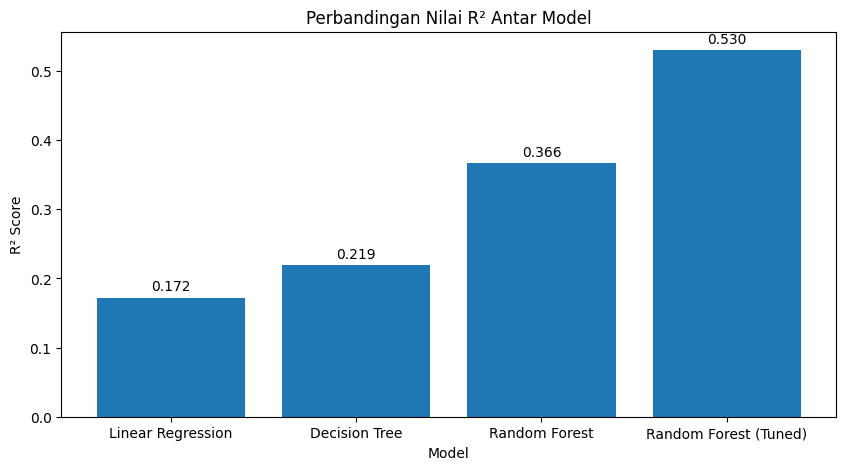

In [48]:
plt.figure(figsize=(10,5))

plt.bar(hasil["Model"], hasil["R2 Score"])

plt.title("Perbandingan Nilai R² Antar Model")
plt.ylabel("R² Score")
plt.xlabel("Model")

for i, v in enumerate(hasil["R2 Score"]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

plt.show()

## Feature Importance

In [117]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
5,production_value,0.458434
4,commodity,0.149849
6,production_unit,0.114319
3,reporting_entity,0.080945
1,parent_entity,0.079657
0,year,0.071938
2,parent_type,0.044858


In [160]:
categorical_columns = [
    'parent_entity',
    'parent_type',
    'reporting_entity',
    'commodity',
    'production_unit'
]

visualisasi

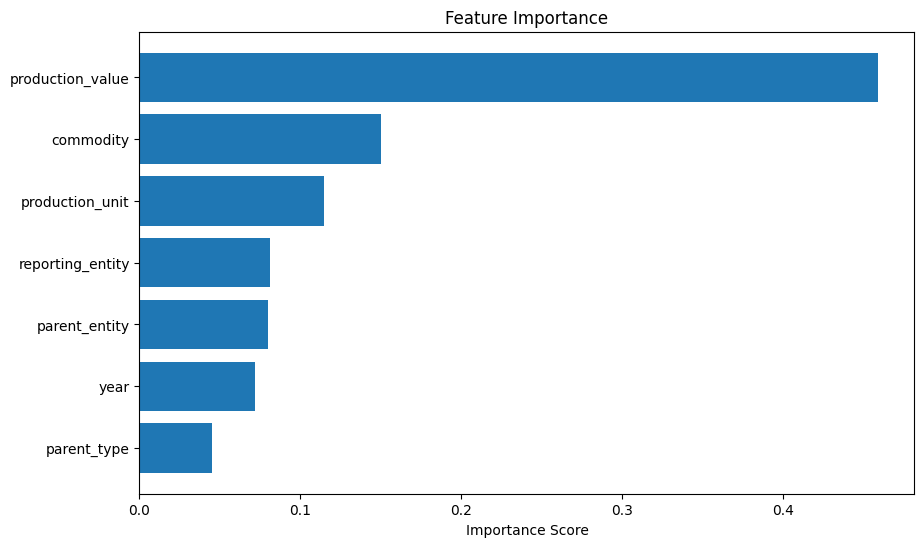

In [161]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance")
plt.xlabel("Importance Score")

plt.show()

## 📈 Interpretasi Feature Importance

Berdasarkan hasil Feature Importance, diperoleh urutan variabel yang paling berpengaruh terhadap prediksi total emisi karbon sebagai berikut:

| Variabel | Importance |
|----------|-----------:|
| Production Value | 0.571 |
| Commodity | 0.092 |
| Year | 0.092 |
| Production Unit | 0.072 |
| Reporting Entity | 0.069 |
| Parent Type | 0.056 |
| Parent Entity | 0.048 |

Hasil tersebut menunjukkan bahwa **Production Value** merupakan variabel yang paling berpengaruh terhadap prediksi total emisi karbon dengan nilai importance sebesar **57,1%**.

Hal ini mengindikasikan bahwa besarnya nilai produksi memiliki hubungan yang kuat terhadap jumlah emisi karbon yang dihasilkan. Semakin besar aktivitas produksi, semakin besar pula potensi emisi karbon yang dihasilkan.

Selain itu, variabel **Commodity** dan **Year** juga memiliki kontribusi yang cukup besar. Jenis komoditas yang diproduksi memengaruhi karakteristik emisi, sedangkan tahun menunjukkan adanya perubahan pola emisi dari waktu ke waktu akibat perkembangan teknologi maupun kebijakan lingkungan.

Variabel lainnya seperti **Production Unit**, **Reporting Entity**, **Parent Type**, dan **Parent Entity** tetap memberikan kontribusi terhadap model meskipun pengaruhnya relatif lebih kecil dibandingkan Production Value.

## SAVE MODEL

In [162]:
import joblib

joblib.dump(best_rf, "model.pkl")

['model.pkl']

Simpan Label Encoder

In [166]:
from sklearn.preprocessing import LabelEncoder

categorical_columns = df_model.select_dtypes(include="object").columns.tolist()

print(categorical_columns)

encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le

[]


In [167]:
joblib.dump(best_rf, "model.pkl")

['model.pkl']